# Probabilidade espacial via Kriging (Rio 2015–2016)

Objetivo: a partir das notificações em `dengue_envs/data/zikario.gpkg`, estimar **como a intensidade de casos se espalha no mapa** e convertê-la em uma **distribuição de probabilidade sobre um grid**.

## Por que agregar antes de krigar?

Há ~100k pontos. Ordinary Kriging clássico é $O(n^3)$ no número de observações — inviável ponto a ponto. O fluxo padrão em mapeamento epidemiológico é:

1. Projetar lon/lat → metros (UTM)
2. Contar casos por célula de um **grid de observação** (ex.: 1 km)
3. Krigar a intensidade (contagem ou $\log(1+c)$) nos centros das células
4. Predizer em um **grid de predição** (mesmo ou mais fino)
5. Normalizar → $P(\text{célula})$ e, entre doenças, $P(\text{doença}\mid\text{célula})$

A EDA exploratória está em `dengue_envs/data/analise_dist.ipynb`. Este notebook foca no **Kriging + mapas de probabilidade**.

In [1]:
from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

# Garante que o pacote do repo seja importável ao rodar o notebook
ROOT = Path.cwd().resolve()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from dengue_envs.data.kriging import (
    DEFAULT_RIO_BBOX_LONLAT,
    GridSpec,
    aggregate_counts,
    bbox_lonlat_to_projected,
    intensity_surface_from_points,
    load_zikario_cases,
    normalize_probability,
    stack_disease_probabilities,
)

sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (10, 8)

GPKG = ROOT / "dengue_envs" / "data" / "zikario.gpkg"
print("dados:", GPKG, "existe=", GPKG.exists())

dados: C:\Users\segun\Documents\GitHub\Dengue_Diagnostics\dengue_envs\data\zikario.gpkg existe= True


## 1. Carregar e limpar os casos

Filtros (iguais à EDA):
- anos 2015–2016 (`DT_SIN_PRI`)
- bbox do Rio
- doenças: Dengue (`A90`), Chikungunya (`A920`), Zika (`A928`)

Coordenadas são projetadas para **EPSG:31983** (metros).

In [2]:
cases = load_zikario_cases(
    GPKG,
    years=(2015, 2016),
    bbox_lonlat=DEFAULT_RIO_BBOX_LONLAT,
    diseases=("Dengue", "Chikungunya", "Zika"),
)

print(cases["Doenca"].value_counts())
print("n=", len(cases))
print("período:", cases["DT_SIN_PRI"].min().date(), "→", cases["DT_SIN_PRI"].max().date())
cases[["Doenca", "latitude", "longitude", "x", "y", "NM_BAIRRO"]].head()

Doenca
Dengue         52255
Zika           40872
Chikungunya    14071
Name: count, dtype: int64
n= 107198
período: 2015-01-01 → 2016-10-22


,Doenca,latitude,longitude,x,y,NM_BAIRRO
0,Dengue,-22.925318,-43.388889,665215.088566,7.463842e+06,TAQUARA
1,Dengue,-22.872878,-43.425393,661533.172395,7.469690e+06,REALENGO
2,Dengue,-22.826738,-43.329702,671409.449550,7.474691e+06,IRAJA
3,Dengue,-22.879648,-43.339151,670373.647776,7.468843e+06,MADUREIRA
4,Dengue,-22.814463,-43.380845,666174.919934,7.476108e+06,PAVUNA


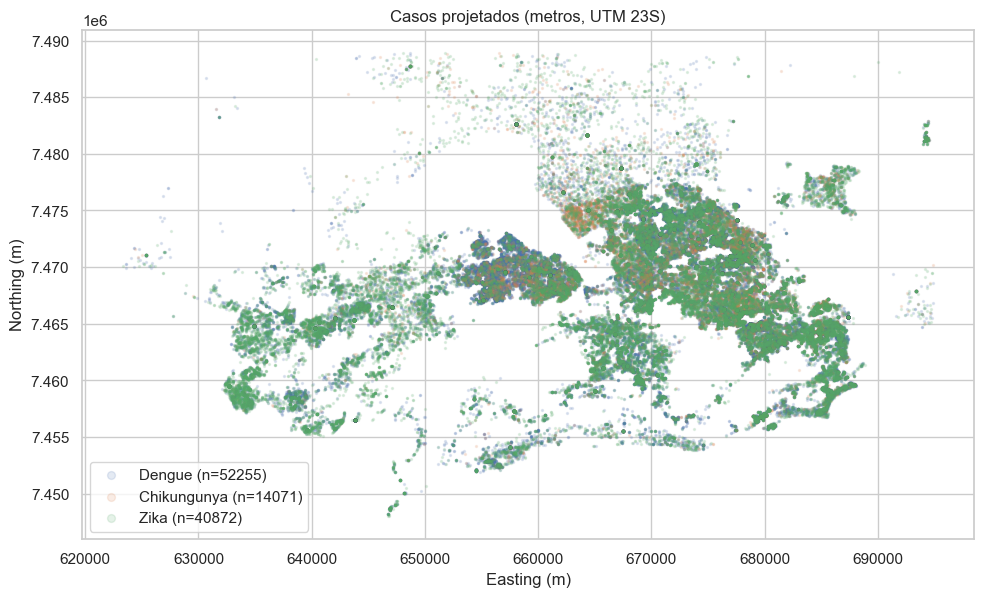

In [3]:
fig, ax = plt.subplots(figsize=(10, 9))
for name, color in [("Dengue", "C0"), ("Chikungunya", "C1"), ("Zika", "C2")]:
    sub = cases[cases["Doenca"] == name]
    ax.scatter(sub["x"], sub["y"], s=2, alpha=0.15, label=f"{name} (n={len(sub)})", c=color)
ax.set_aspect("equal")
ax.set_title("Casos projetados (metros, UTM 23S)")
ax.set_xlabel("Easting (m)")
ax.set_ylabel("Northing (m)")
ax.legend(markerscale=4)
plt.tight_layout()
plt.show()

## 2. Grid de observação — contagens brutas

Começamos com células de **1 km**. Isso vira o campo $z$ que o Kriging vai interpolar.

Dica: se a superfície ficar muito “pixelada”, diminua `OBS_CELL_M` (ex.: 500). Se o Kriging ficar lento ou instável, aumente (ex.: 1500–2000).

bbox (m): x=[622893, 695168] y=[7444144, 7489191]
grid obs: 145 × 91 = 13195 células
pontos dentro do grid: 107198 | soma contagens: 107198


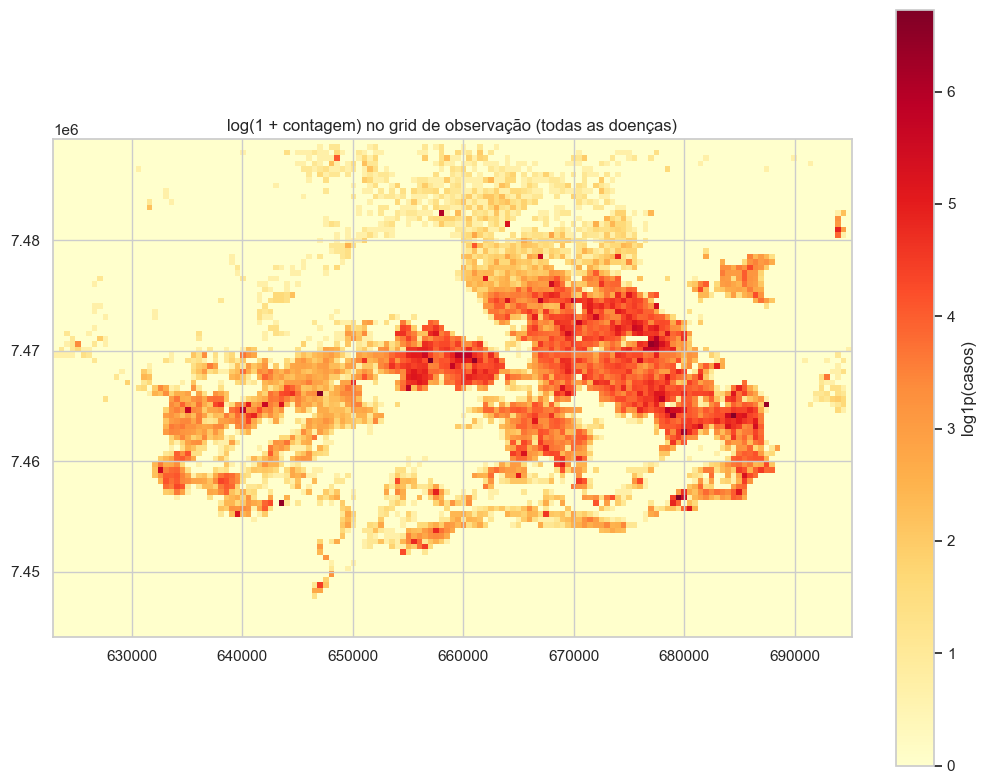

In [5]:
OBS_CELL_M = 500.0   # agregação (m)
PRED_CELL_M = 500.0   # predição mais fina (m)

xmin, xmax, ymin, ymax = bbox_lonlat_to_projected(DEFAULT_RIO_BBOX_LONLAT)
obs_grid = GridSpec(xmin, xmax, ymin, ymax, OBS_CELL_M)
print(f"bbox (m): x=[{xmin:.0f}, {xmax:.0f}] y=[{ymin:.0f}, {ymax:.0f}]")
print(f"grid obs: {obs_grid.nx} × {obs_grid.ny} = {obs_grid.nx * obs_grid.ny} células")

count_all = aggregate_counts(cases["x"].to_numpy(), cases["y"].to_numpy(), obs_grid)
print("pontos dentro do grid:", count_all.n_points, "| soma contagens:", count_all.total)

fig, ax = plt.subplots(figsize=(10, 8))
extent = [xmin, xmax, ymin, ymax]
im = ax.imshow(
    np.log1p(count_all.counts),
    origin="lower",
    extent=extent,
    aspect="equal",
    cmap="YlOrRd",
)
ax.set_title("log(1 + contagem) no grid de observação (todas as doenças)")
plt.colorbar(im, ax=ax, fraction=0.046, label="log1p(casos)")
plt.tight_layout()
plt.show()

## 3. Ordinary Kriging → superfície de intensidade

Usamos $\log(1+c)$ como variável (estabiliza hotspots). O modelo de variograma padrão é **spherical** (bom default epidemiológico); experimente também `exponential` e `gaussian`.

Abaixo: uma superfície **por doença**, depois a probabilidade espacial $P(x,y\mid\text{doença})$.

In [6]:
VARIOGRAM = "spherical"  # tente: "exponential", "gaussian", "linear"

results = {}
for disease in ("Dengue", "Chikungunya", "Zika"):
    sub = cases[cases["Doenca"] == disease]
    counts, intensity, sigma, pred_grid = intensity_surface_from_points(
        sub["x"].to_numpy(),
        sub["y"].to_numpy(),
        bbox_xy=(xmin, xmax, ymin, ymax),
        obs_cell_size=OBS_CELL_M,
        pred_cell_size=PRED_CELL_M,
        transform="log1p",
        variogram_model=VARIOGRAM,
    )
    prob = normalize_probability(intensity)
    results[disease] = {
        "counts": counts,
        "intensity": intensity,
        "sigma": sigma,
        "prob": prob,
        "pred_grid": pred_grid,
        "n": len(sub),
    }
    print(
        f"{disease:12s} n={len(sub):6d}  "
        f"células obs>0={(counts.counts > 0).sum():4d}  "
        f"P soma={prob.sum():.6f}  max P={prob.max():.3e}"
    )

pred_grid = results["Dengue"]["pred_grid"]
extent = [pred_grid.xmin, pred_grid.xmax, pred_grid.ymin, pred_grid.ymax]

Dengue       n= 52255  células obs>0=3085  P soma=1.000000  max P=2.391e-04
Chikungunya  n= 14071  células obs>0=2009  P soma=1.000000  max P=2.057e-04
Zika         n= 40872  células obs>0=3269  P soma=1.000000  max P=1.526e-04


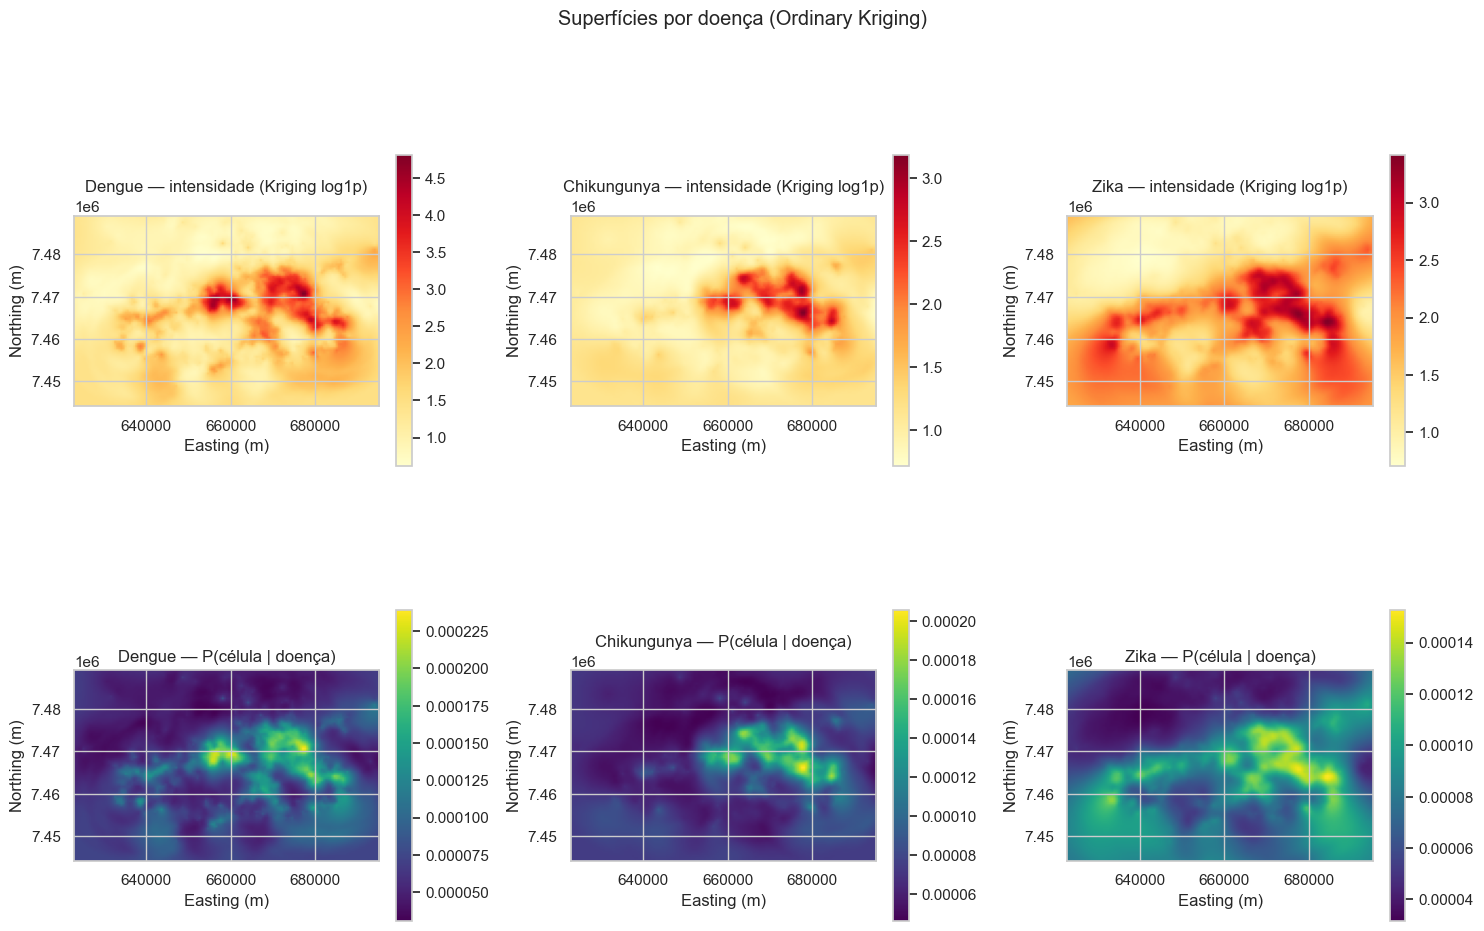

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, disease in enumerate(("Dengue", "Chikungunya", "Zika")):
    r = results[disease]
    ax0, ax1 = axes[0, i], axes[1, i]

    im0 = ax0.imshow(r["intensity"], origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
    ax0.set_title(f"{disease} — intensidade (Kriging log1p)")
    plt.colorbar(im0, ax=ax0, fraction=0.046)

    im1 = ax1.imshow(r["prob"], origin="lower", extent=extent, aspect="equal", cmap="viridis")
    ax1.set_title(f"{disease} — P(célula | doença)")
    plt.colorbar(im1, ax=ax1, fraction=0.046)

for ax in axes.ravel():
    ax.set_xlabel("Easting (m)")
    ax.set_ylabel("Northing (m)")

plt.suptitle("Superfícies por doença (Ordinary Kriging)", y=1.01)
plt.tight_layout()
plt.show()

## 4. Incerteza do Kriging e $P(\text{doença}\mid\text{célula})$

- **sigma**: variância de predição (maior longe dos dados / em áreas sem casos).
- **stack**: em cada célula, normalizamos as intensidades das 3 doenças → probabilidade de classe espacial.

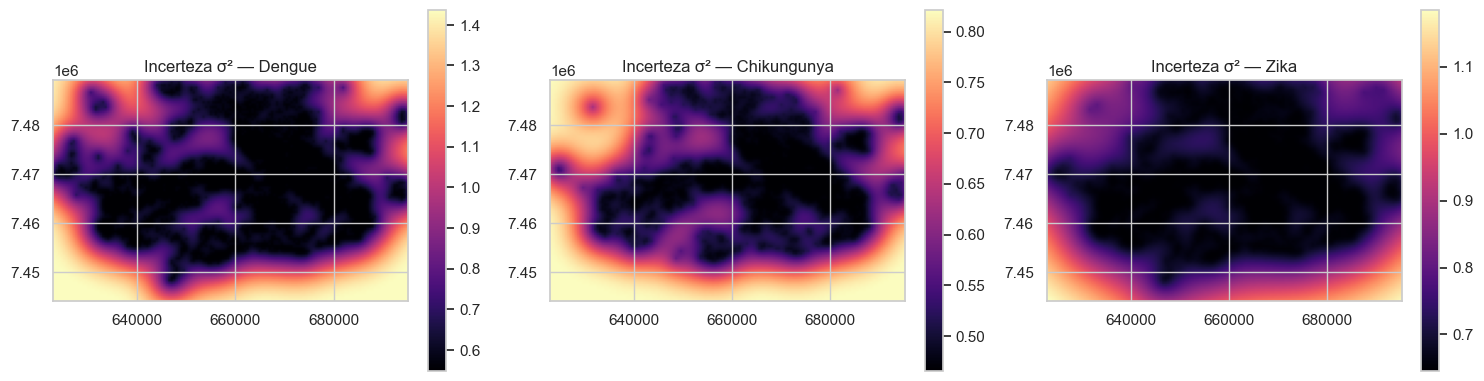

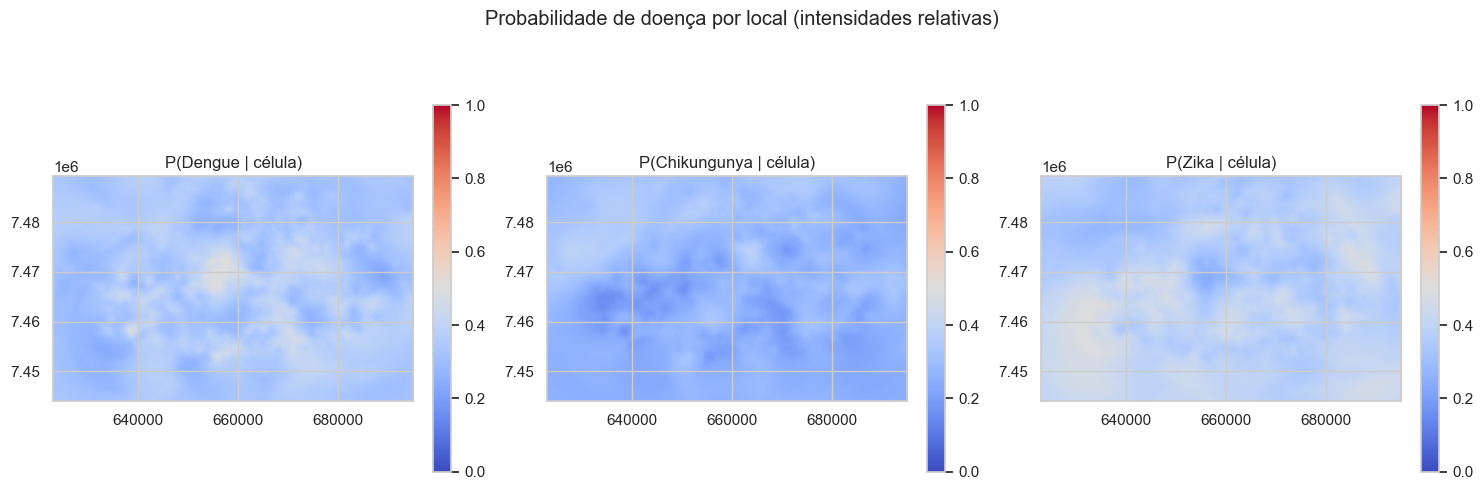

soma P(doença|célula): min/mean/max = 0.9999999999999998 1.0 1.0000000000000002


In [8]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, disease in zip(axes, ("Dengue", "Chikungunya", "Zika")):
    im = ax.imshow(results[disease]["sigma"], origin="lower", extent=extent, aspect="equal", cmap="magma")
    ax.set_title(f"Incerteza σ² — {disease}")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.tight_layout()
plt.show()

class_probs = stack_disease_probabilities({d: results[d]["intensity"] for d in results})

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
for ax, disease in zip(axes, ("Dengue", "Chikungunya", "Zika")):
    im = ax.imshow(class_probs[disease], origin="lower", extent=extent, aspect="equal", cmap="coolwarm", vmin=0, vmax=1)
    ax.set_title(f"P({disease} | célula)")
    plt.colorbar(im, ax=ax, fraction=0.046)
plt.suptitle("Probabilidade de doença por local (intensidades relativas)", y=1.02)
plt.tight_layout()
plt.show()

# Sanidade: em cada célula as 3 probs somam ~1
stack_sum = sum(class_probs[d] for d in class_probs)
print("soma P(doença|célula): min/mean/max =", stack_sum.min(), stack_sum.mean(), stack_sum.max())

## 5. Mapa composto + contornos

Visualização única: probabilidade espacial da Dengue com contornos e pontos (amostra) por cima.

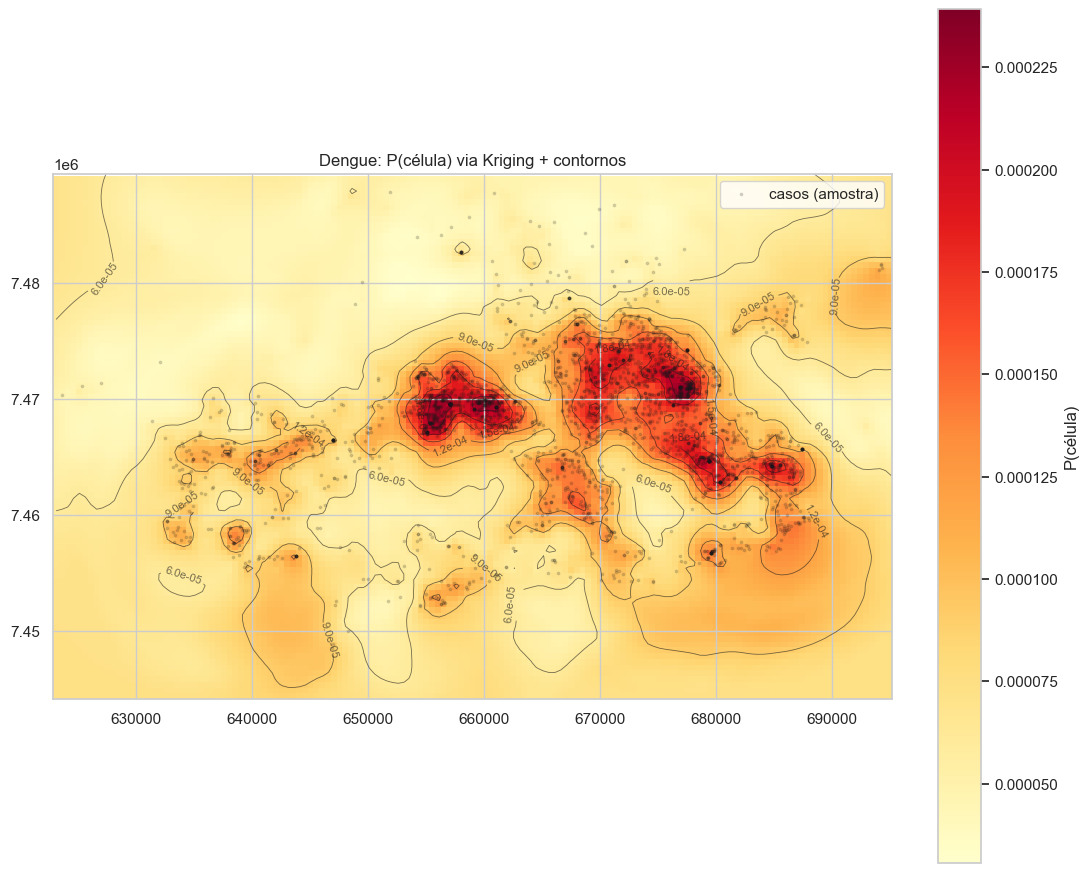

In [9]:
disease = "Dengue"
prob = results[disease]["prob"]
xs, ys = pred_grid.centers()
XX, YY = np.meshgrid(xs, ys)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(prob, origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
cs = ax.contour(XX, YY, prob, levels=6, colors="k", linewidths=0.6, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8, fmt=lambda v: f"{v:.1e}")

sample = cases[cases["Doenca"] == disease].sample(n=min(3000, results[disease]["n"]), random_state=0)
ax.scatter(sample["x"], sample["y"], s=3, c="k", alpha=0.15, label="casos (amostra)")

ax.set_title(f"{disease}: P(célula) via Kriging + contornos")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, fraction=0.046, label="P(célula)")
plt.tight_layout()
plt.show()

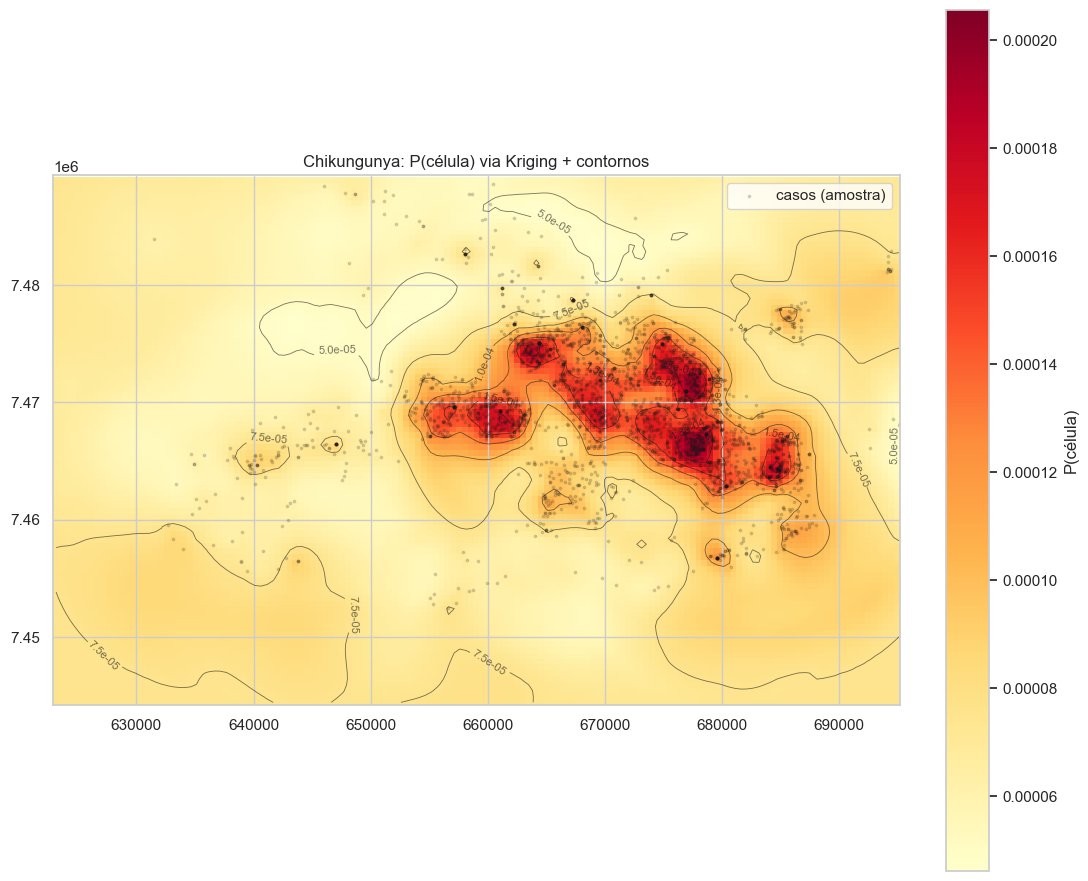

In [ ]:
disease = "Chikungunya"
prob = results[disease]["prob"]
xs, ys = pred_grid.centers()
XX, YY = np.meshgrid(xs, ys)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(prob, origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
cs = ax.contour(XX, YY, prob, levels=6, colors="k", linewidths=0.6, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8, fmt=lambda v: f"{v:.1e}")

sample = cases[cases["Doenca"] == disease].sample(n=min(3000, results[disease]["n"]), random_state=0)
ax.scatter(sample["x"], sample["y"], s=3, c="k", alpha=0.15, label="casos (amostra)")

ax.set_title(f"{disease}: P(célula) via Kriging + contornos")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, fraction=0.046, label="P(célula)")
plt.tight_layout()
plt.show()

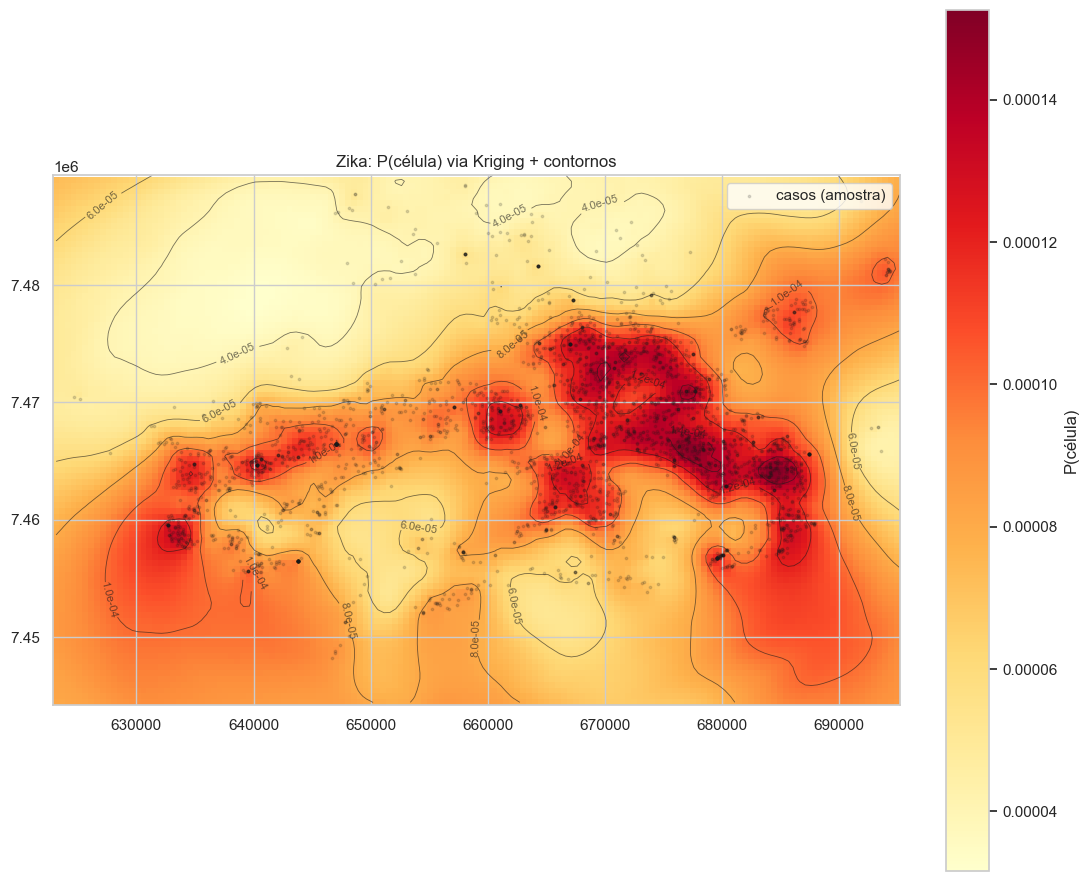

In [13]:
disease = "Zika"
prob = results[disease]["prob"]
xs, ys = pred_grid.centers()
XX, YY = np.meshgrid(xs, ys)

fig, ax = plt.subplots(figsize=(11, 9))
im = ax.imshow(prob, origin="lower", extent=extent, aspect="equal", cmap="YlOrRd")
cs = ax.contour(XX, YY, prob, levels=6, colors="k", linewidths=0.6, alpha=0.6)
ax.clabel(cs, inline=True, fontsize=8, fmt=lambda v: f"{v:.1e}")

sample = cases[cases["Doenca"] == disease].sample(n=min(3000, results[disease]["n"]), random_state=0)
ax.scatter(sample["x"], sample["y"], s=3, c="k", alpha=0.15, label="casos (amostra)")

ax.set_title(f"{disease}: P(célula) via Kriging + contornos")
ax.legend(loc="upper right")
plt.colorbar(im, ax=ax, fraction=0.046, label="P(célula)")
plt.tight_layout()
plt.show()

## 6. Como a epidemia se espalha no tempo (fatias mensais)

Kriging **por mês** (só Dengue, para não ficar pesado). Compare hotspots mês a mês — isso antecipa um gerador espaço-temporal.

meses usados: [Period('2015-01', 'M'), Period('2015-02', 'M'), Period('2015-03', 'M'), Period('2015-04', 'M'), Period('2015-05', 'M'), Period('2015-06', 'M'), Period('2015-07', 'M'), Period('2015-08', 'M')]


C:\Users\segun\AppData\Local\Temp\ipykernel_24144\33555126.py:38: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


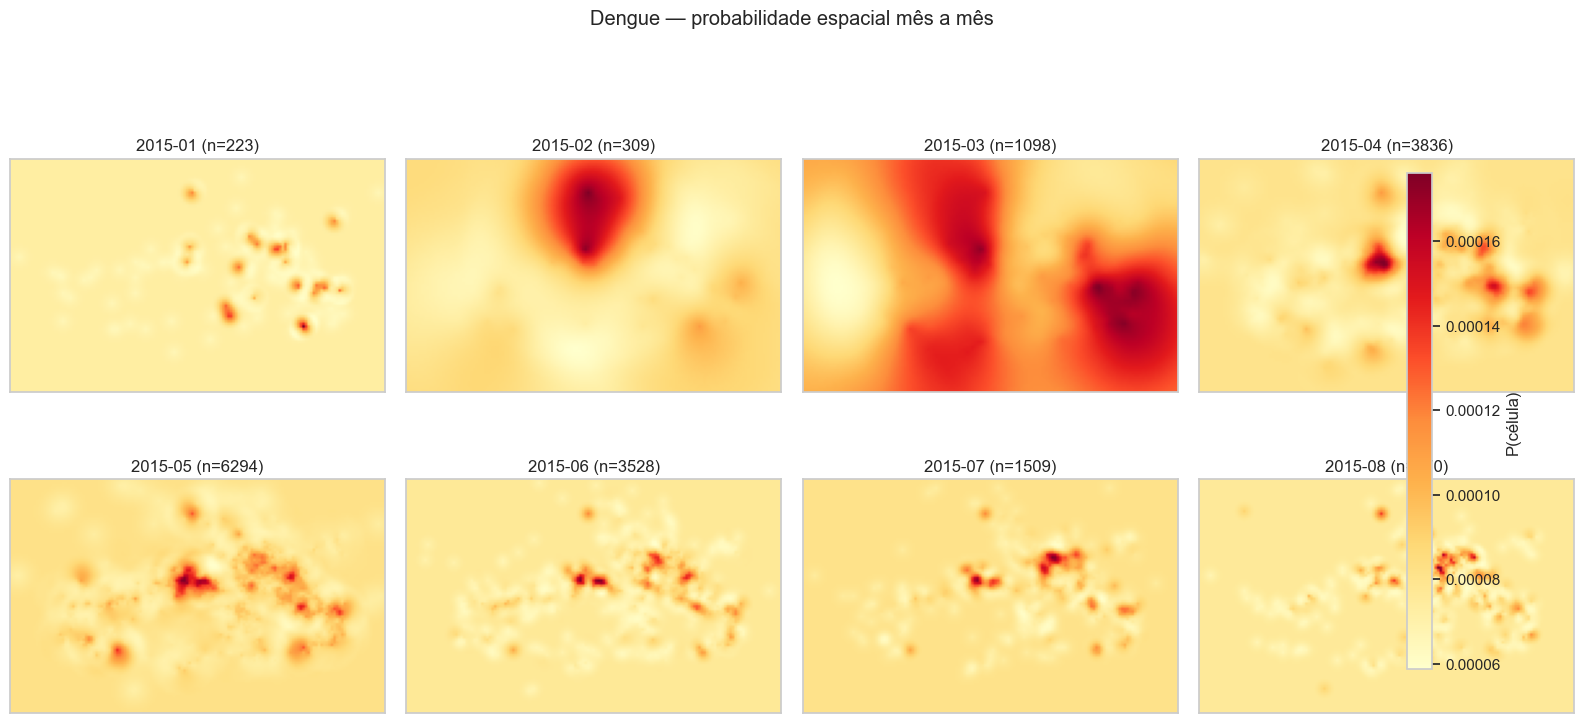

: 

In [ ]:
dengue = cases[cases["Doenca"] == "Dengue"].copy()
dengue["AnoMes"] = dengue["DT_SIN_PRI"].dt.to_period("M")

# Meses com volume razoável
month_counts = dengue["AnoMes"].value_counts().sort_index()
months = [m for m, n in month_counts.items() if n >= 200][:8]  # até 8 painéis
print("meses usados:", months)

n = len(months)
ncols = 4
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(4 * ncols, 4 * nrows))
axes = np.atleast_2d(axes)

for ax, month in zip(axes.ravel(), months):
    sub = dengue[dengue["AnoMes"] == month]
    _, intensity, _, pg = intensity_surface_from_points(
        sub["x"].to_numpy(),
        sub["y"].to_numpy(),
        bbox_xy=(xmin, xmax, ymin, ymax),
        obs_cell_size=OBS_CELL_M,
        pred_cell_size=PRED_CELL_M,
        transform="log1p",
        variogram_model=VARIOGRAM,
    )
    prob = normalize_probability(intensity)
    ext = [pg.xmin, pg.xmax, pg.ymin, pg.ymax]
    im = ax.imshow(prob, origin="lower", extent=ext, aspect="equal", cmap="YlOrRd")
    ax.set_title(f"{month} (n={len(sub)})")
    ax.set_xticks([])
    ax.set_yticks([])

for ax in axes.ravel()[n:]:
    ax.axis("off")

fig.colorbar(im, ax=axes.ravel().tolist(), fraction=0.02, label="P(célula)")
plt.suptitle("Dengue — probabilidade espacial mês a mês", y=1.01)
plt.tight_layout()
plt.show()

## 7. Exportar o grid de probabilidade (para o ambiente depois)

Salva `.npz` com as superfícies — base futura do `KrigingDensityGenerator` / amostragem no `World`.

In [ ]:
out_dir = ROOT / "results" / "kriging"
out_dir.mkdir(parents=True, exist_ok=True)

payload = {
    "crs": "EPSG:31983",
    "bbox_lonlat": DEFAULT_RIO_BBOX_LONLAT,
    "xmin": pred_grid.xmin,
    "xmax": pred_grid.xmax,
    "ymin": pred_grid.ymin,
    "ymax": pred_grid.ymax,
    "cell_size": pred_grid.cell_size,
    "variogram_model": VARIOGRAM,
    "obs_cell_size": OBS_CELL_M,
}
for disease, r in results.items():
    key = disease.lower()
    payload[f"intensity_{key}"] = r["intensity"]
    payload[f"prob_{key}"] = r["prob"]
    payload[f"sigma_{key}"] = r["sigma"]
    payload[f"class_prob_{key}"] = class_probs[disease]

out_path = out_dir / "rio_2015_2016_kriging_surfaces.npz"
np.savez_compressed(out_path, **payload)
print("salvo:", out_path)
print("chaves:", sorted(np.load(out_path).files))

## Próximos passos

1. Ajustar `OBS_CELL_M` / `PRED_CELL_M` / variograma até o mapa “parecer” o surto real.
2. Ligar o `.npz` ao `KrigingDensityGenerator` — já implementado:
   ```bash
   poetry run python -m dengue_envs.data.build_kriging_surfaces
   poetry run python agents/qlearning/train.py --config experiments/configs/train/qlearning_kriging.yaml
   ```
   YAML: `experiments/configs/env/kriging_rio.yaml` (`generator: kriging`).
3. Usar `P(doença|célula)` (ou intensidade) no `epi_confirm` no lugar do limiar binário.
4. (Opcional) Kriging espaço-temporal por semana epidemiológica.

Para rodar este notebook:

```bash
poetry install
poetry run jupyter notebook notebooks/kriging_spatial_probability.ipynb
```